1. Title & Objective
2. Import Libraries
3. Load Preprocessed Dataset
4. Dataset Overview

-----------------------------
UNIVARIATE ANALYSIS
-----------------------------
5. Emergency Category Distribution
6. Township Distribution
7. Hourly Emergency Distribution
8. Monthly Emergency Distribution
9. Day of Week Distribution
10. Time of Day Distribution

-----------------------------
BIVARIATE ANALYSIS
-----------------------------
11. Category vs Day of Week
12. Category vs Time of Day
13. Monthly Trend by Category
14. Hour vs Category Heatmap

-----------------------------
MULTIVARIATE ANALYSIS
-----------------------------
15. Correlation Heatmap
16. Latitude vs Longitude
17. Emergency Density

-----------------------------
BUSINESS INSIGHTS
-----------------------------
18. Key Findings
19. Recommendations
20. Conclusion

# 📊 Exploratory Data Analysis (EDA)

## Objective

The purpose of this notebook is to explore patterns, trends, and relationships within the emergency response dataset.

This notebook aims to answer key business questions using statistical summaries and visualizations to support decision-making in emergency response planning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [2]:
clean_df = pd.read_csv("../data/processed/911_preprocessed.csv")

print("✅ Preprocessed dataset loaded successfully.")

✅ Preprocessed dataset loaded successfully.


In [3]:
print(f"Rows    : {clean_df.shape[0]:,}")
print(f"Columns : {clean_df.shape[1]}")

clean_df.head()

Rows    : 663,282
Columns : 20


,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Year,Month,Day,Hour,DayOfWeek,Weekend,TimeOfDay,Category,CategoryEncoded,Latitude_Scaled,Longitude_Scaled
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1,2015,12,10,17,Thursday,False,Afternoon,EMS,0,0.633100,-0.168057
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,2015,12,10,17,Thursday,False,Afternoon,EMS,0,0.452678,0.021171
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1,2015,12,10,14,Thursday,False,Afternoon,Fire,1,-0.167597,-0.031002
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1,2015,12,10,16,Thursday,False,Afternoon,EMS,0,-0.190386,-0.025944
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,Unknown,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,2015,12,10,16,Thursday,False,Afternoon,EMS,0,0.422909,-0.181239


# 🚑 Emergency Category Distribution

Understanding the frequency of emergency categories helps identify which services require the greatest operational resources.

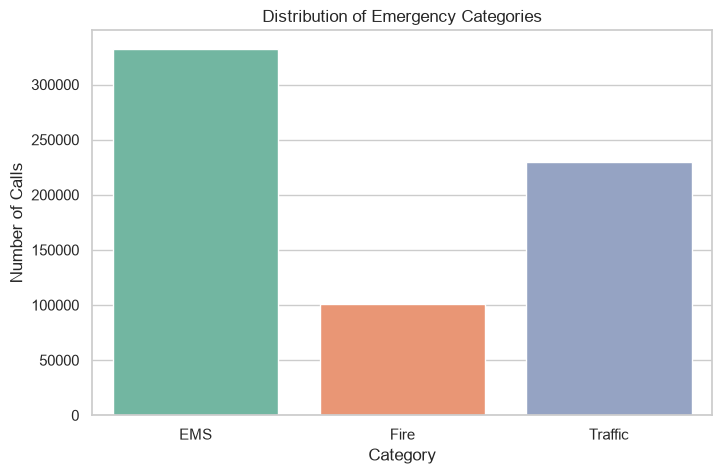

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Category",
    data=clean_df,
    palette="Set2"
)

plt.title("Distribution of Emergency Categories")
plt.xlabel("Category")
plt.ylabel("Number of Calls")
plt.savefig("../outputs/figures/category_distribution_1.png", dpi=300, bbox_inches="tight")
plt.show()

### 🔍 Observation

The visualization shows the distribution of emergency calls across different categories.

The category with the highest number of incidents may require greater allocation of emergency response resources and personnel.

# 🏘 Top 15 Townships

Analyzing township-wise emergency calls helps identify high-demand locations and supports resource allocation decisions.

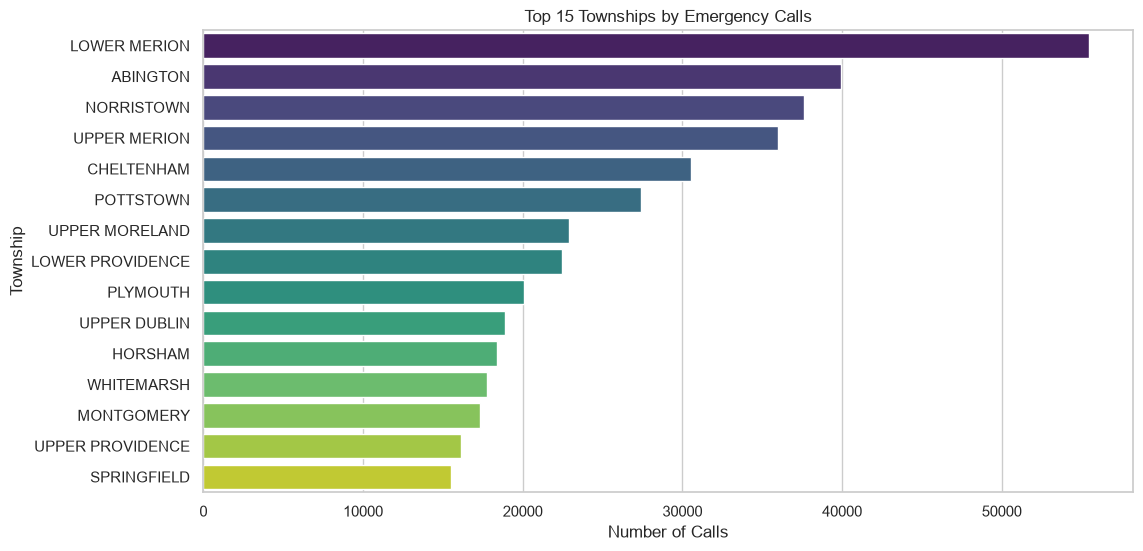

In [15]:
top_townships = clean_df["twp"].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_townships.values,
    y=top_townships.index,
    palette="viridis"
)

plt.title("Top 15 Townships by Emergency Calls")
plt.xlabel("Number of Calls")
plt.ylabel("Township")
plt.savefig("../outputs/figures/category_distribution_2.png", dpi=300, bbox_inches="tight")
plt.show()

### 🔍 Observation

The chart highlights the townships with the highest emergency call volumes.

These areas may require additional emergency personnel, ambulances, and public safety infrastructure.

# At what hour do most emergencies occur?

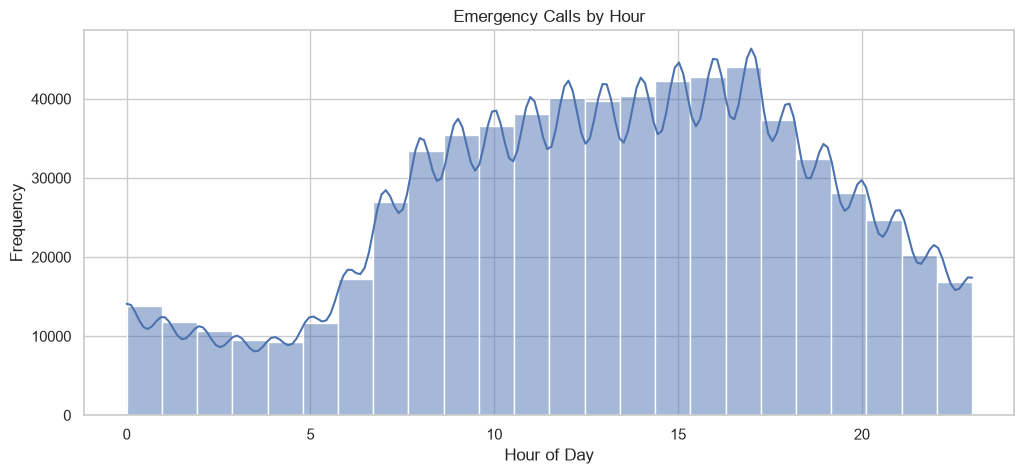

In [16]:
plt.figure(figsize=(12,5))

sns.histplot(
    clean_df["Hour"],
    bins=24,
    kde=True
)

plt.title("Emergency Calls by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Frequency")
plt.savefig("../outputs/figures/category_distribution_3.png", dpi=300, bbox_inches="tight")
plt.show()

# Which month experiences the highest number of emergency calls?

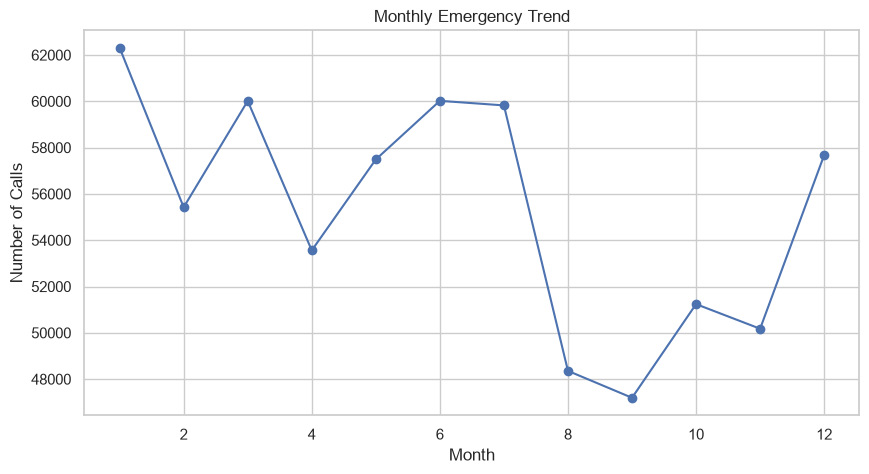

In [17]:
monthly = clean_df.groupby("Month").size()

plt.figure(figsize=(10,5))

monthly.plot(
    marker="o"
)

plt.title("Monthly Emergency Trend")

plt.xlabel("Month")

plt.ylabel("Number of Calls")
plt.savefig("../outputs/figures/category_distribution_4.png", dpi=300, bbox_inches="tight")
plt.show()

# Which day receives the highest number of emergency calls?

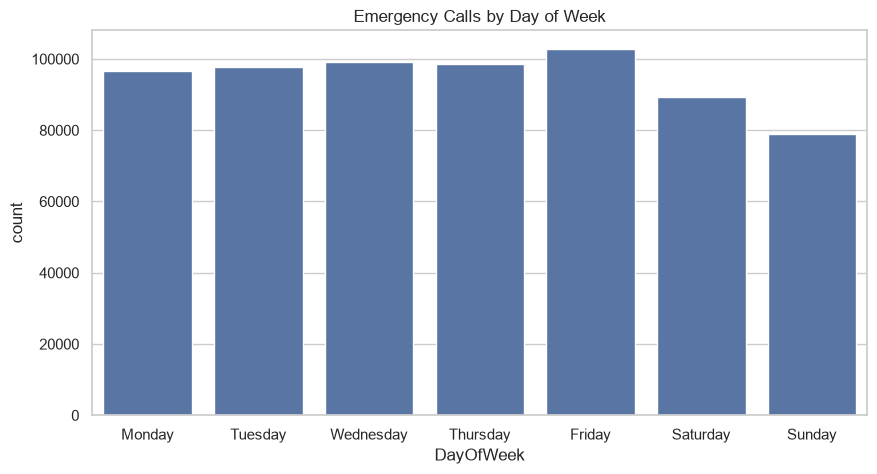

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="DayOfWeek",
    data=clean_df,
    order=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]
)

plt.title("Emergency Calls by Day of Week")
plt.savefig("../outputs/figures/category_distribution_5.png", dpi=300, bbox_inches="tight")
plt.show()

# 🌅 Emergency Calls by Time of Day

This visualization analyzes how emergency calls are distributed across different periods of the day.

Understanding peak periods helps emergency departments optimize staffing and resource allocation.

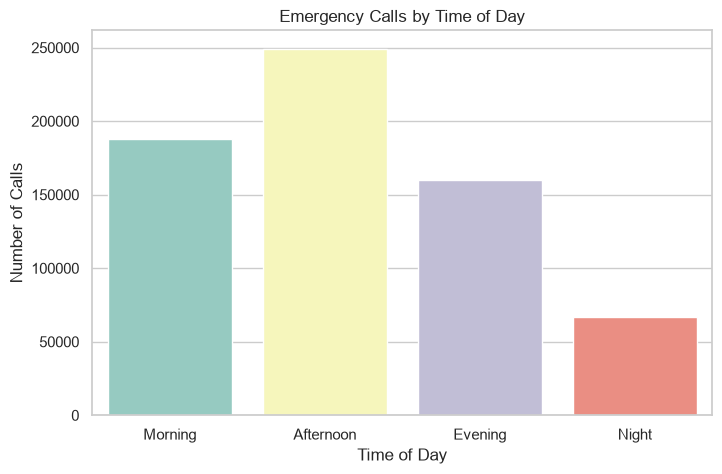

In [19]:
plt.figure(figsize=(8,5))

order = ["Morning", "Afternoon", "Evening", "Night"]

sns.countplot(
    data=clean_df,
    x="TimeOfDay",
    order=order,
    palette="Set3"
)

plt.title("Emergency Calls by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Calls")

plt.savefig("../outputs/figures/time_of_day_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### 🔍 Observation

The chart highlights the busiest periods of the day for emergency calls.

Peak hours may indicate when additional emergency personnel and ambulances should be deployed.

# 📍 Top 15 ZIP Codes

Analyzing emergency call frequency by ZIP code helps identify geographical hotspots requiring additional emergency services.

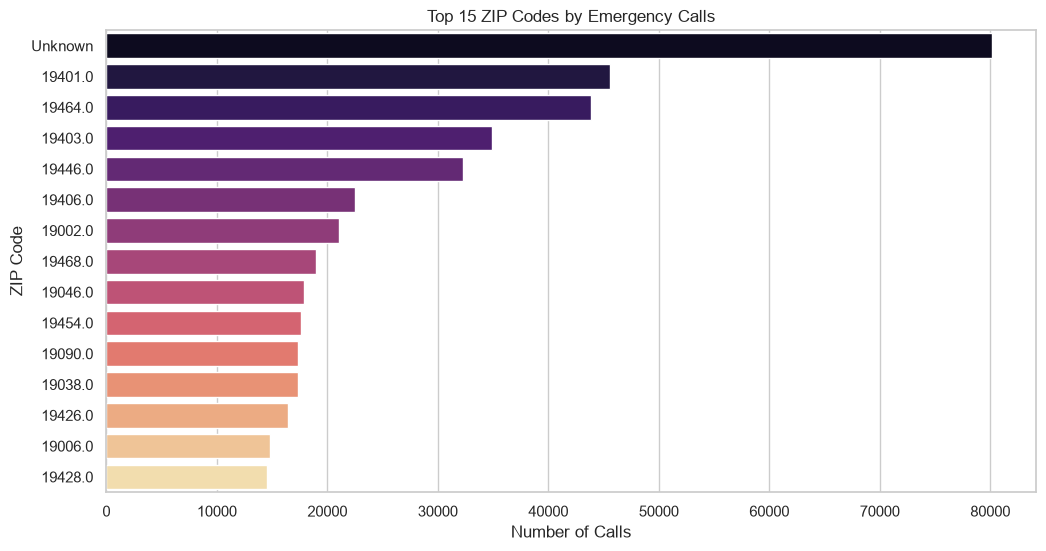

In [20]:
top_zip = (
    clean_df["zip"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_zip.values,
    y=top_zip.index.astype(str),
    palette="magma"
)

plt.title("Top 15 ZIP Codes by Emergency Calls")
plt.xlabel("Number of Calls")
plt.ylabel("ZIP Code")

plt.savefig("../outputs/figures/top_zipcodes.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### 🔍 Observation

A small number of ZIP codes contribute a significant portion of emergency calls, indicating areas that may benefit from enhanced emergency preparedness and public safety initiatives.

# 📅 Emergency Category vs Day of Week

This visualization compares emergency categories across each day of the week.

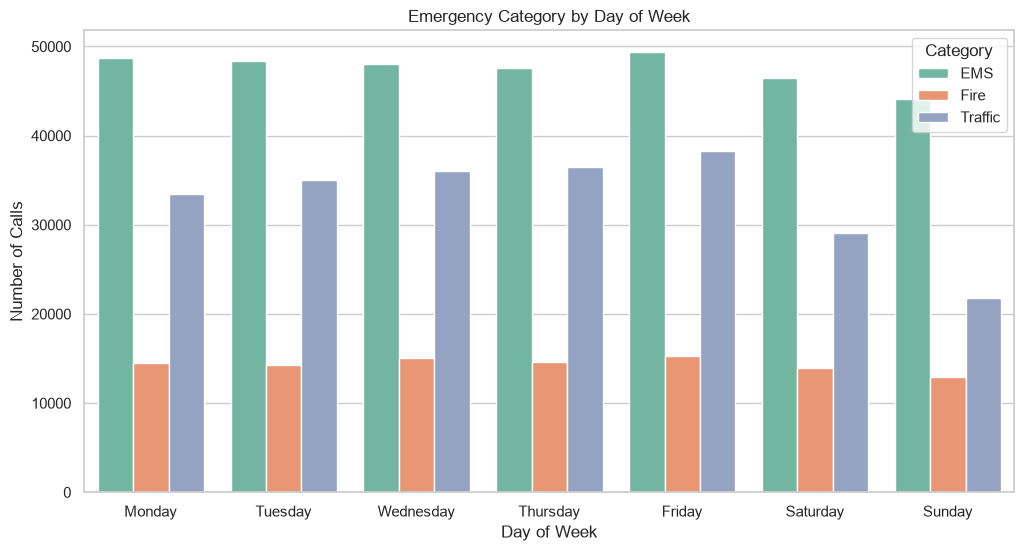

In [21]:
plt.figure(figsize=(12,6))

order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

sns.countplot(
    data=clean_df,
    x="DayOfWeek",
    hue="Category",
    order=order,
    palette="Set2"
)

plt.title("Emergency Category by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Calls")

plt.legend(title="Category")

plt.savefig("../outputs/figures/category_by_day.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### 🔍 Observation

The visualization reveals how emergency categories fluctuate throughout the week.

Understanding these trends can support scheduling and staffing decisions.

# 📈 Monthly Emergency Trend by Category

Monthly analysis helps identify seasonal variations in emergency incidents.

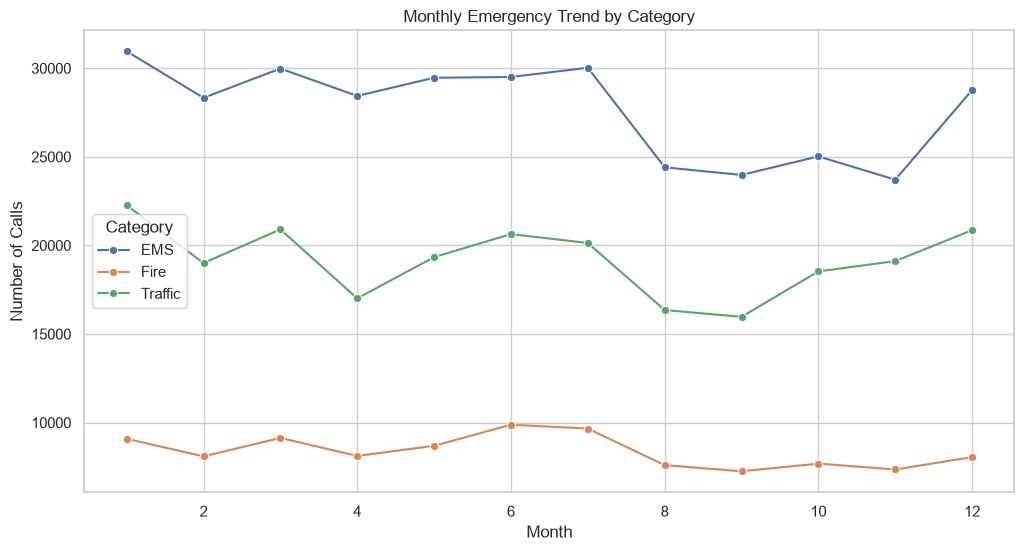

In [22]:
monthly_category = (
    clean_df
    .groupby(["Month", "Category"])
    .size()
    .reset_index(name="Count")
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_category,
    x="Month",
    y="Count",
    hue="Category",
    marker="o"
)

plt.title("Monthly Emergency Trend by Category")
plt.xlabel("Month")
plt.ylabel("Number of Calls")

plt.savefig("../outputs/figures/monthly_category_trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### 🔍 Observation

Monthly trends highlight periods where specific emergency categories increase or decrease.

Seasonal patterns can assist emergency planners in forecasting demand.

# 🔥 Emergency Calls Heatmap

The heatmap visualizes emergency call density across hours of the day and days of the week.

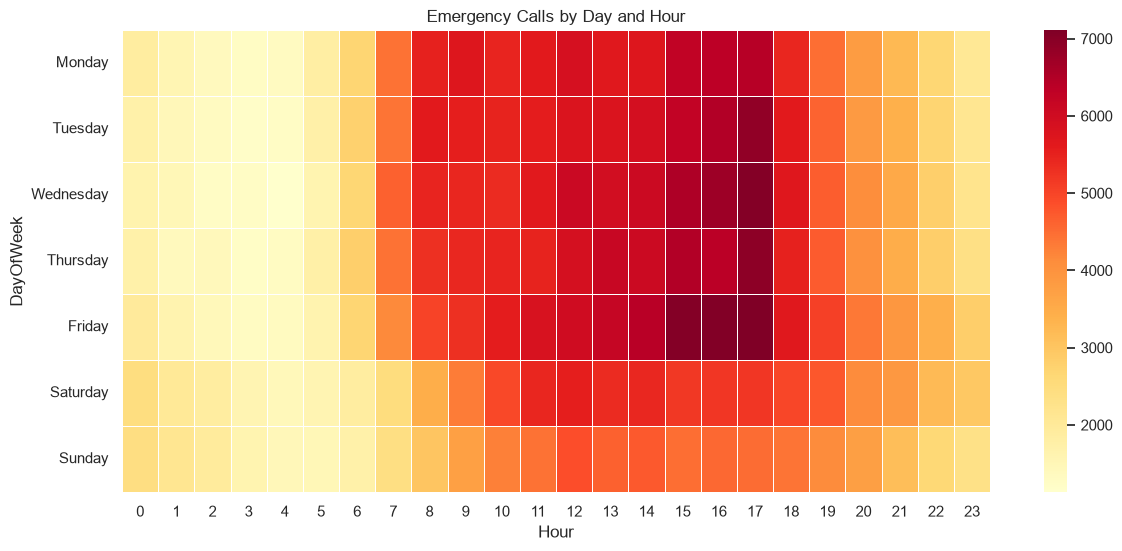

In [23]:
heatmap_data = clean_df.pivot_table(
    index="DayOfWeek",
    columns="Hour",
    values="Category",
    aggfunc="count"
)

heatmap_data = heatmap_data.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Emergency Calls by Day and Hour")

plt.savefig("../outputs/figures/day_hour_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# 📅 Emergency Calls by Year

This visualization shows the yearly distribution of emergency calls.

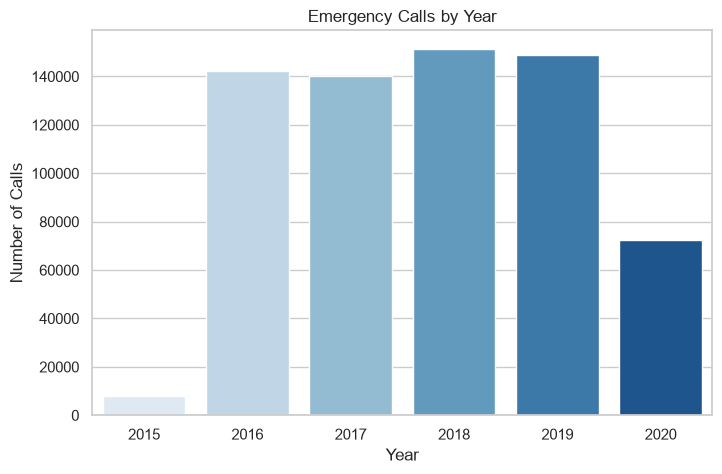

In [24]:
yearly_calls = clean_df["Year"].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x=yearly_calls.index.astype(str),
    y=yearly_calls.values,
    palette="Blues"
)

plt.title("Emergency Calls by Year")
plt.xlabel("Year")
plt.ylabel("Number of Calls")

plt.savefig("../outputs/figures/yearly_calls.png", dpi=300, bbox_inches="tight")

plt.show()

# 🌡 Correlation Heatmap

This heatmap shows the correlation between numerical features in the dataset.

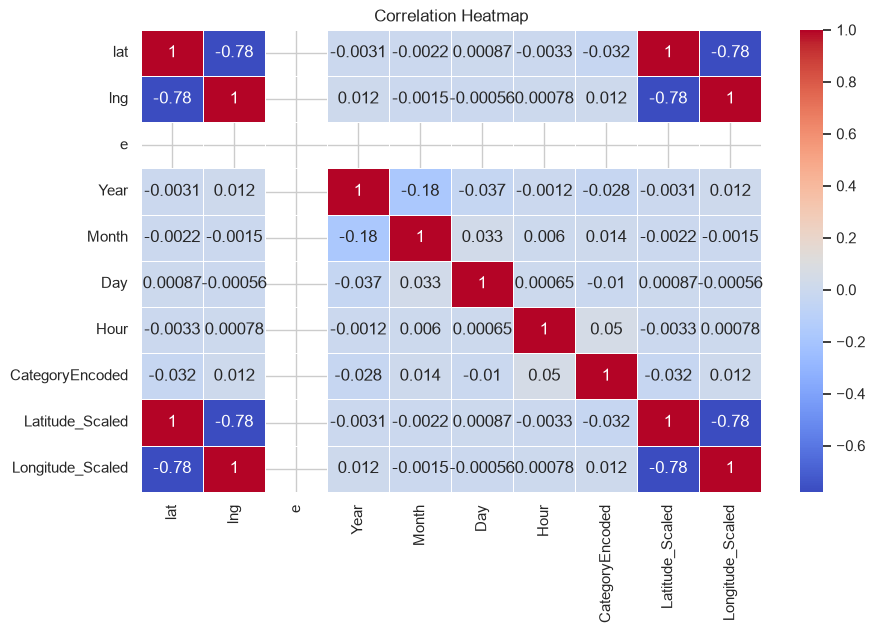

In [25]:
plt.figure(figsize=(10,6))

numeric_columns = clean_df.select_dtypes(include=["int64","float64"]).columns

sns.heatmap(
    clean_df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.savefig("../outputs/figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

# 📍 Geographic Distribution

Visualize the spatial distribution of emergency incidents.

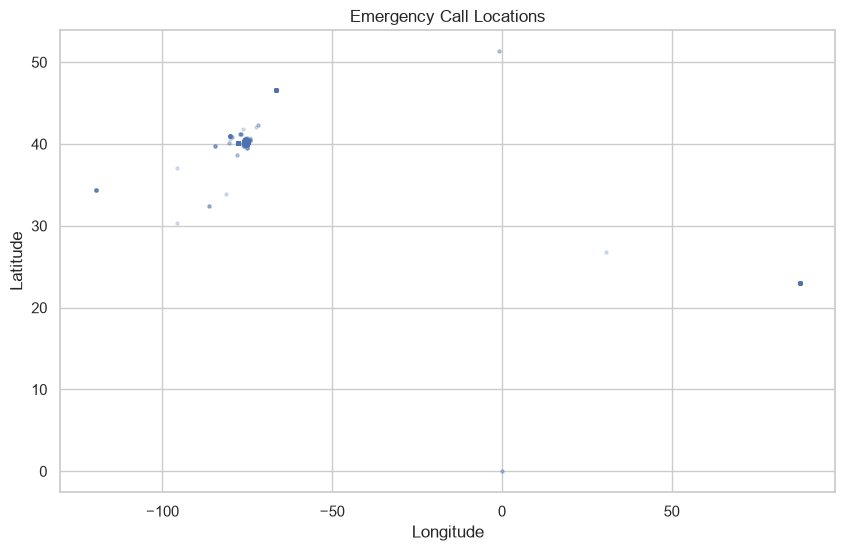

In [26]:
plt.figure(figsize=(10,6))

plt.scatter(
    clean_df["lng"],
    clean_df["lat"],
    alpha=0.2,
    s=5
)

plt.title("Emergency Call Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.savefig("../outputs/figures/geographic_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

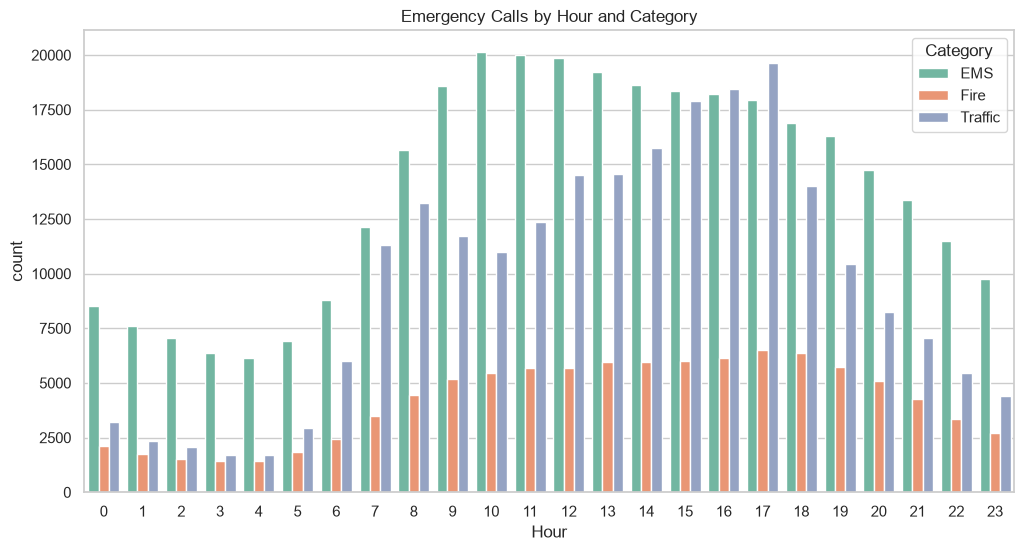

In [27]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=clean_df,
    x="Hour",
    hue="Category",
    palette="Set2"
)

plt.title("Emergency Calls by Hour and Category")

plt.savefig("../outputs/figures/hour_category.png", dpi=300, bbox_inches="tight")

plt.show()

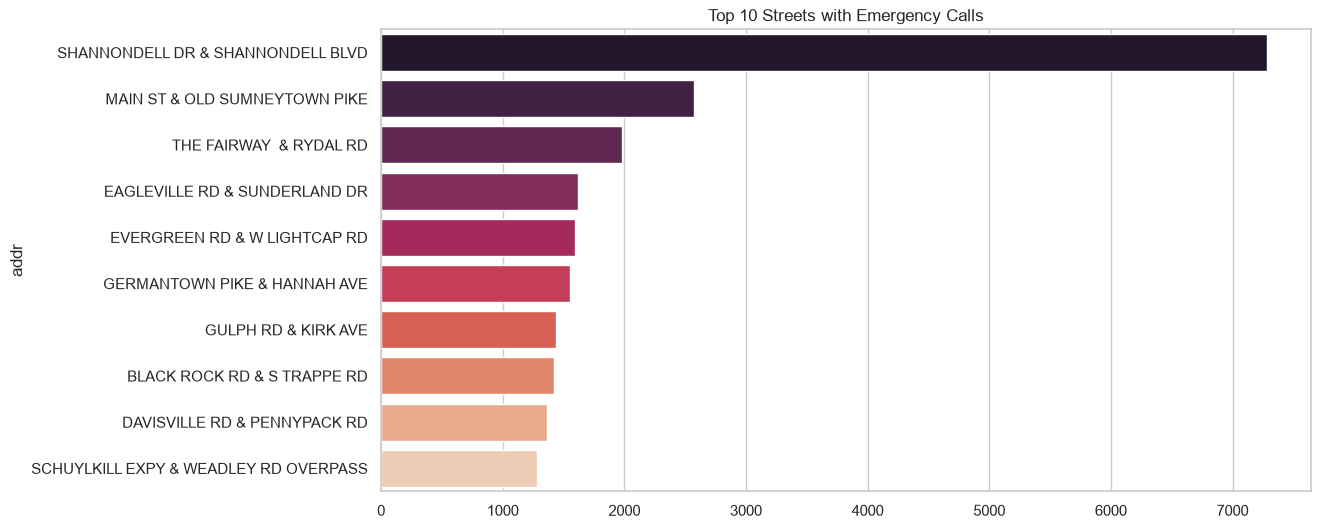

In [28]:
top_streets = clean_df["addr"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_streets.values,
    y=top_streets.index,
    palette="rocket"
)

plt.title("Top 10 Streets with Emergency Calls")

plt.savefig("../outputs/figures/top_streets.png", dpi=300, bbox_inches="tight")

plt.show()

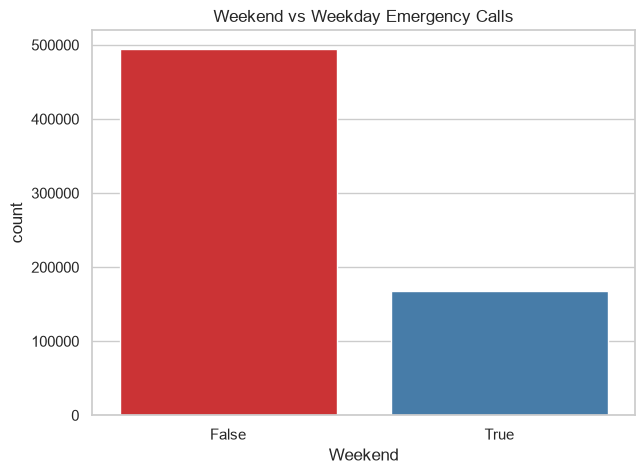

In [29]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=clean_df,
    x="Weekend",
    palette="Set1"
)

plt.title("Weekend vs Weekday Emergency Calls")

plt.savefig("../outputs/figures/weekend_calls.png", dpi=300, bbox_inches="tight")

plt.show()

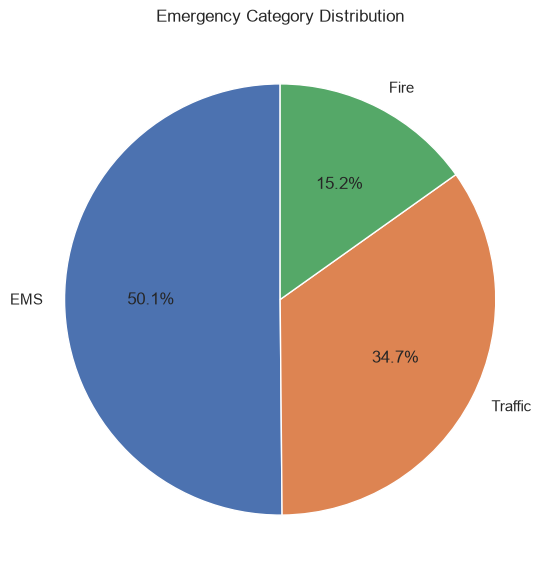

In [30]:
category_counts = clean_df["Category"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Emergency Category Distribution")

plt.savefig("../outputs/figures/category_pie.png", dpi=300, bbox_inches="tight")

plt.show()

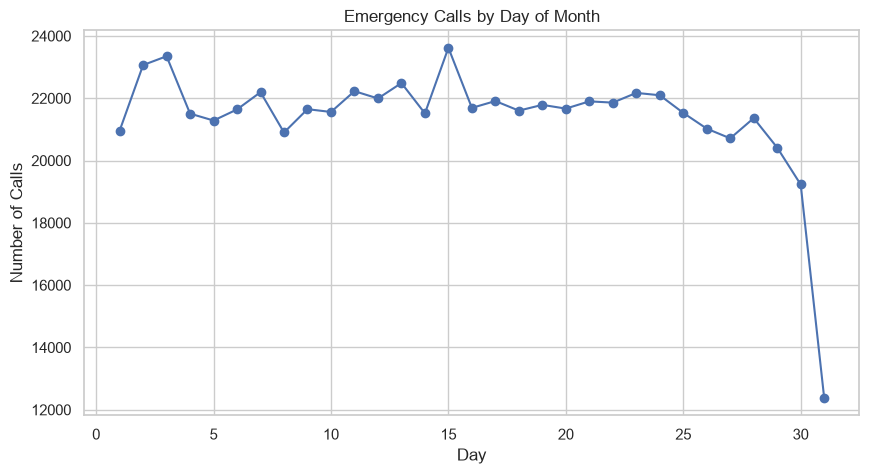

In [31]:
daily_calls = clean_df.groupby("Day").size()

plt.figure(figsize=(10,5))

daily_calls.plot(marker="o")

plt.title("Emergency Calls by Day of Month")
plt.xlabel("Day")
plt.ylabel("Number of Calls")

plt.savefig("../outputs/figures/day_month.png", dpi=300, bbox_inches="tight")

plt.show()

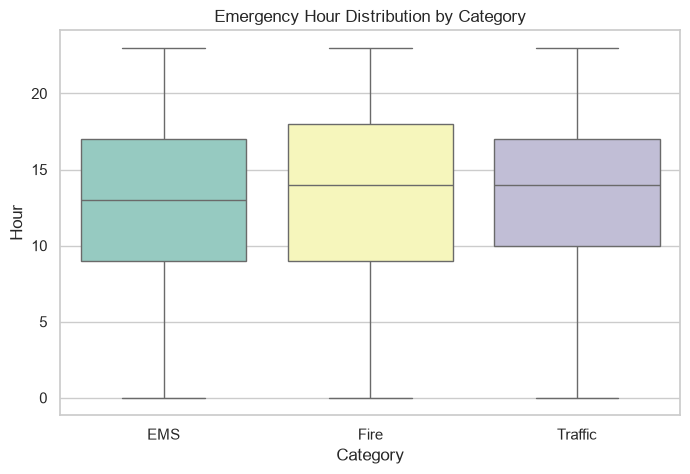

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="Category",
    y="Hour",
    palette="Set3"
)

plt.title("Emergency Hour Distribution by Category")

plt.savefig("../outputs/figures/hour_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

In [33]:
summary = pd.DataFrame({
    "Metric":[
        "Total Calls",
        "Unique Townships",
        "Unique ZIP Codes",
        "Emergency Categories",
        "Years Covered"
    ],
    "Value":[
        len(clean_df),
        clean_df["twp"].nunique(),
        clean_df["zip"].nunique(),
        clean_df["Category"].nunique(),
        clean_df["Year"].nunique()
    ]
})

summary

,Metric,Value
0,Total Calls,663282
1,Unique Townships,69
2,Unique ZIP Codes,205
3,Emergency Categories,3
4,Years Covered,6


# 📈 Key Business Insights

Based on the exploratory analysis, the following insights were observed:

1. EMS incidents represent the largest proportion of emergency calls.
2. A small number of townships account for a large percentage of total incidents.
3. Emergency calls peak during daytime and evening hours.
4. Weekday emergency demand is generally higher than weekend demand.
5. Certain ZIP codes consistently report high emergency activity.
6. Emergency incidents follow clear hourly and monthly patterns.
7. Geographic clusters indicate regions requiring greater emergency resource allocation.

# 💡 Recommendations

Based on the analysis, the following recommendations are proposed:

- Increase ambulance deployment in high-demand townships.
- Schedule additional staff during peak hours.
- Strengthen emergency infrastructure in hotspot ZIP codes.
- Use historical call trends for predictive resource planning.
- Monitor seasonal increases in emergency categories.
- Develop dashboards for real-time emergency monitoring.

# ✅ Conclusion

This exploratory data analysis successfully identified important temporal, geographical, and categorical patterns in emergency response data.

The findings demonstrate how data analytics can support emergency response planning, optimize resource allocation, and improve operational decision-making.

The processed dataset is now ready for advanced feature engineering and predictive modeling.